In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/advertising.csv"

df = pd.read_csv(url)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


In [3]:
print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


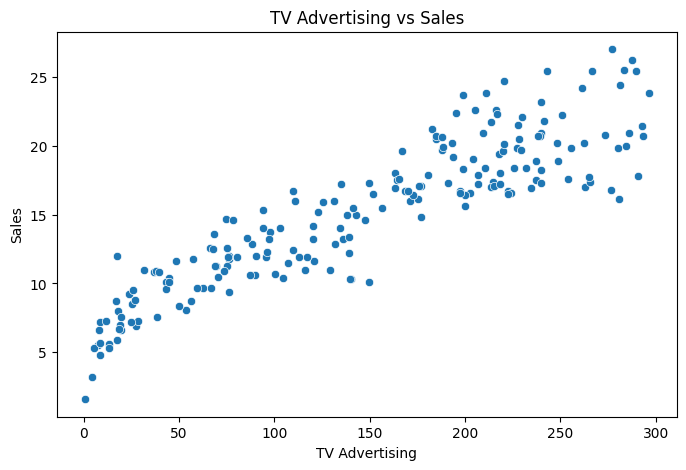

In [4]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='TV', y='Sales')

plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')

plt.show()

In [5]:
correlation = df.corr(numeric_only=True)

print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


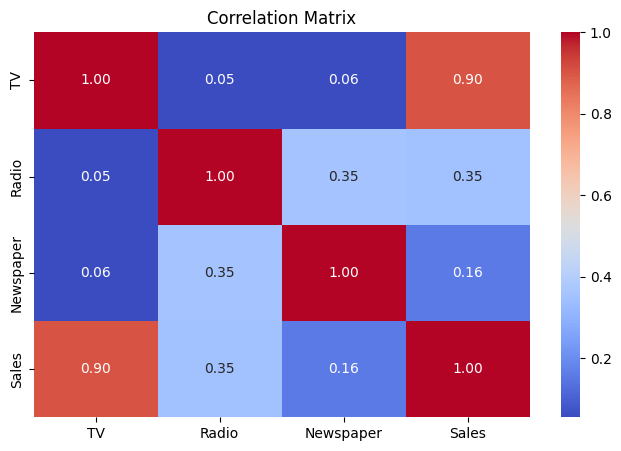

In [6]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

In [7]:
# Input features
X = df[['TV', 'Radio', 'Newspaper']]

# Target variable
y = df['Sales']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

Feature shape: (200, 3)
Target shape: (200,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [10]:
y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 10 Actual Sales:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted Sales:")
print(y_pred[:10])

Predictions completed!

First 10 Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 16.5 16.1]

First 10 Predicted Sales:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation:
MAE  : 1.2748262109549338
MSE  : 2.9077569102710896
RMSE : 1.7052146229349223
R²   : 0.9059011844150826


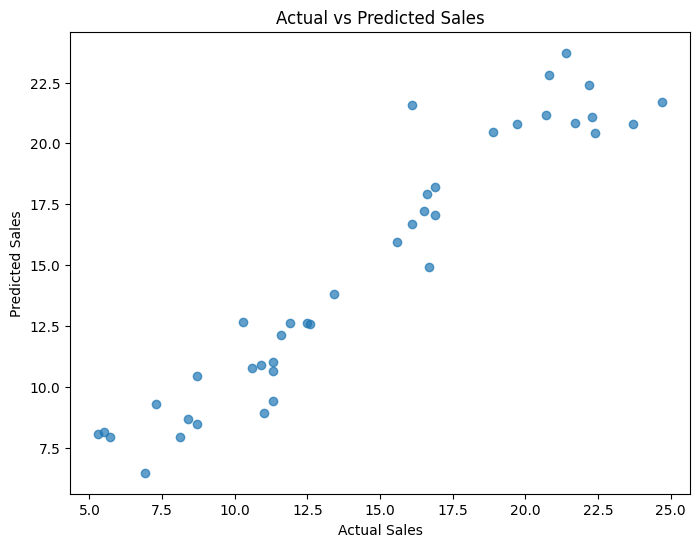

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [13]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [14]:
from google.colab import files

files.download("sales_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>